# Taller B3-T4 — Redes Neuronales para Forecasting
## Ventana entrada: 30 dias | Ventana salida: 5 dias

- **Parte 1 — Competicion**: entrenar y comparar modelos sobre log-retornos en bruto
- **Parte 2 — Investigacion**: aplicar preprocesado del Taller B3-T1 (Lopez de Prado) y evaluar su efecto


In [1]:
VENTANA_ENTRADA = 30   # dias de entrada
VENTANA_SALIDA  = 5   # dias de salida (promedio)


In [2]:
import sys
sys.path.insert(0, '..')
import importlib
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity
from statsmodels.tsa.stattools import adfuller
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import utilidades.modelos as modelos_mod
from utilidades.carga_datos import cargar_retornos, create_time_series_data, dividir_datos, aplanar_X
from utilidades.modelos import (
    construir_baseline_lineal,
    construir_dense,
    construir_dense_v2,
    construir_dense_v3,
    construir_dense_v4,
    construir_dense_v5,
    construir_dense_v6,
    construir_recurrente,
    construir_conv1d,
    construir_mixto,
    construir_dense_param,
    construir_dense_v2_param,
    construir_dense_v3_param,
    construir_dense_v4_param,
    construir_dense_v5_param,
    construir_dense_v6_param,
    construir_lstm_param,
    construir_conv1d_param,
    construir_mixto_param,
    ofat_search,
    successive_halving_search,
    plot_best_history,
)
from utilidades.evaluacion import evaluar_modelo, evaluar_sklearn, evaluar_buyhold, guardar_resultados
from utilidades.graficos import graficar_convergencia, graficar_barras_mae

CALLBACKS = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=1),
]


---
# PARTE 1 — Competicion
Modelos sobre log-retornos en bruto. Metrica: MAE medio sobre 23 activos.


## 1.1 Carga de datos

In [3]:
retornos = cargar_retornos()
X, y = create_time_series_data(retornos, VENTANA_ENTRADA, VENTANA_SALIDA)
print(f'X: {X.shape}  |  y: {y.shape}')
X_train, X_val, X_test, y_train, y_val, y_test = dividir_datos(X, y)
X_train_plano = aplanar_X(X_train)
X_val_plano   = aplanar_X(X_val)
X_test_plano  = aplanar_X(X_test)
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


X: (16156, 30, 23)  |  y: (16156, 23)
Train: (13813, 30, 23)  Val: (727, 30, 23)  Test: (1616, 30, 23)


## 1.2 Baselines

In [4]:
reg_lineal = LinearRegression()
reg_lineal.fit(X_train_plano, y_train)
resultado_lineal = evaluar_sklearn(
    reg_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')
resultado_bah = evaluar_buyhold(y_train, y_val, y_test)
print(pd.DataFrame([resultado_lineal, resultado_bah]).set_index('modelo').round(6))


            mae_train   mae_val  mae_test  n_params
modelo                                             
Lineal       0.005268  0.004482  0.005872         0
BuyAndHold   0.005396  0.004302  0.005585         0


## 1.3 Modelo Dense (MLP)


In [5]:
modelo_lineal = construir_baseline_lineal(X_train_plano.shape[1], y_train.shape[1])
modelo_lineal.summary()
hist_dense_lineal = modelo_lineal.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
   epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Lineal_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 23)             │        15,893 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,893 (62.08 KB)

 Trainable params: 15,893 (62.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0189 - val_loss: 0.0149 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0181 - val_loss: 0.0144 - learning_rate: 0.0010
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0174 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0167 - val_loss: 0.0134 - learning_rate: 0.0010
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0161 - val_loss: 0.0130 - learning_rate: 0.0010
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0155 - val_loss: 0.0126 - learning_rate: 0.0010
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0150 - val_loss: 0.0123 - learning_rate: 0.0010
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0145 - val_loss: 0.0119 - learning_rate: 0.0010
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0141 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 

In [6]:
modelo_dense_1 = construir_dense(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_1.summary()
hist_dense_1 = modelo_dense_1.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)


Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       176,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,759 (831.09 KB)

 Trainable params: 212,759 (831.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - loss: 0.0152 - val_loss: 0.0077 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0113 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0099
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0097 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0081 - val_loss: 0.0054 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0075 - val_loss: 0.0050 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0070
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0070 - val_loss: 0.0048 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0066 - val_loss: 0.0047 - le

In [7]:
modelo_dense_2 = construir_dense_v2(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_2.summary()
hist_dense_2 = modelo_dense_2.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)


Model: "Dense_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        88,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,543 (388.84 KB)

 Trainable params: 99,543 (388.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0165 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0107 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0083
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0080 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0071 - val_loss: 0.0053 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0067 - val_loss: 0.0051 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0065
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0064 - val_loss: 0.0049 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0062 - val_loss: 0.0047 - le

In [8]:
modelo_dense_3 = construir_dense_v3(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_3.summary()
hist_dense_3 = modelo_dense_3.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)


Model: "Dense_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │       353,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527,767 (2.01 MB)

 Trainable params: 527,767 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - loss: 0.0107 - val_loss: 0.0068 - learning_rate: 1.0000e-04
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0092 - val_loss: 0.0059 - learning_rate: 1.0000e-04
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0083
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0081 - val_loss: 0.0054 - learning_rate: 1.0000e-04
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0075 - val_loss: 0.0052 - learning_rate: 5.0000e-05
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0072 - val_loss: 0.0051 - learning_rate: 5.0000e-05
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0070
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0070 - val_loss: 0.0050 - learning_rate: 5.0000e-05
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0068 - val_loss:

In [9]:
modelo_dense_4 = construir_dense_v4(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_4.summary()
hist_dense_4 = modelo_dense_4.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)


Model: "Dense_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 128)            │        88,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,199 (383.59 KB)

 Trainable params: 98,199 (383.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0450 - val_loss: 0.0360 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0396 - val_loss: 0.0339 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0367
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0364 - val_loss: 0.0325 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0343 - val_loss: 0.0317 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0332 - val_loss: 0.0308 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0323
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0322 - val_loss: 0.0299 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0313 - val_loss: 0.0294 - le

In [10]:
modelo_dense_5 = construir_dense_v5(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_5.summary()
hist_dense_5 = modelo_dense_5.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)


Model: "Dense_v5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │       176,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,807 (714.09 KB)

 Trainable params: 182,807 (714.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - loss: 0.0240 - val_loss: 0.0155 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0210 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0192
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0190 - val_loss: 0.0126 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0177 - val_loss: 0.0120 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0170 - val_loss: 0.0114 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0166
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0164 - val_loss: 0.0108 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0158 - val_loss: 0.0105 - le

In [11]:
modelo_dense_6 = construir_dense_v6(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_6.summary()
hist_dense_6 = modelo_dense_6.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)


Model: "Dense_v6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 32)             │        22,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,511 (138.71 KB)

 Trainable params: 35,511 (138.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 0.0190 - val_loss: 0.0110 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0164 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0147
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0144 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0126 - val_loss: 0.0077 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0119 - val_loss: 0.0073 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0114
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0113 - val_loss: 0.0069 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0108 - val_loss: 0.0067 - le

{'modelo': 'Lineal', 'mae_train': 0.0054651933148027855, 'mae_val': 0.004692926517720439, 'mae_test': 0.006121583964206029, 'n_params': 15893}


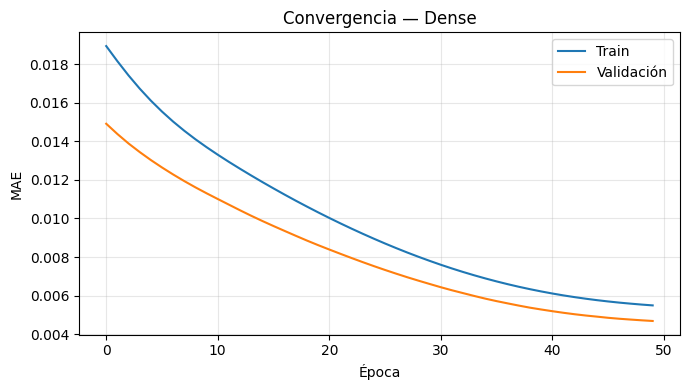

In [12]:
graficar_convergencia(hist_dense_lineal, 'Dense')
resultado_lineal = evaluar_modelo(modelo_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')
print(resultado_lineal)


{'modelo': 'Dense', 'mae_train': 0.0054033274706069175, 'mae_val': 0.004317816499884593, 'mae_test': 0.005643282814914641, 'n_params': 212759}


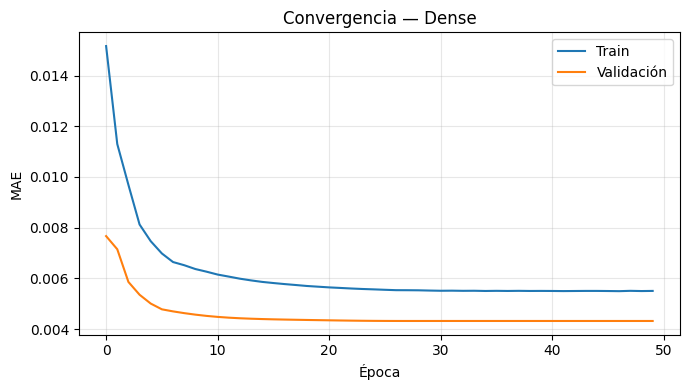

In [13]:
graficar_convergencia(hist_dense_1, 'Dense')
resultado_dense_1 = evaluar_modelo(modelo_dense_1, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_1)


{'modelo': 'Dense', 'mae_train': 0.00548360413136911, 'mae_val': 0.004402271638214606, 'mae_test': 0.005679027193677932, 'n_params': 99543}


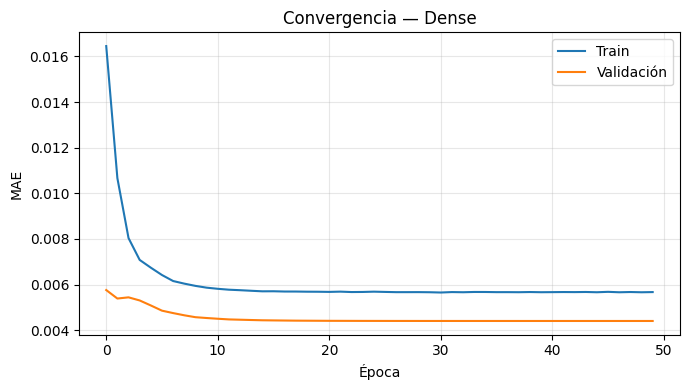

In [14]:
graficar_convergencia(hist_dense_2, 'Dense')
resultado_dense_2 = evaluar_modelo(modelo_dense_2, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_2)


{'modelo': 'Dense', 'mae_train': 0.0059626375548680515, 'mae_val': 0.004741971838227505, 'mae_test': 0.006266477482674099, 'n_params': 527767}


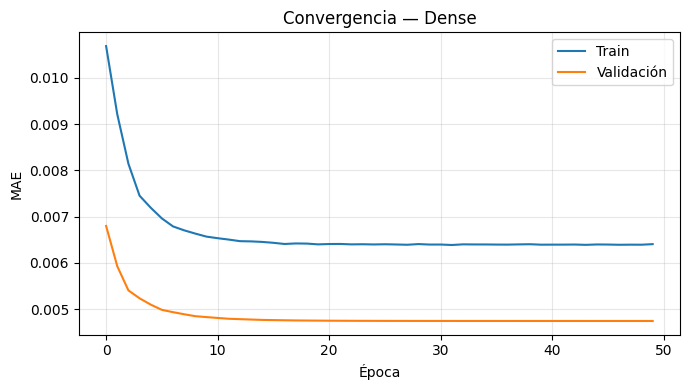

In [15]:
graficar_convergencia(hist_dense_3, 'Dense')
resultado_dense_3 = evaluar_modelo(modelo_dense_3, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_3)


{'modelo': 'Dense', 'mae_train': 0.0056865601449557724, 'mae_val': 0.004559106915309317, 'mae_test': 0.005961744228670973, 'n_params': 98199}


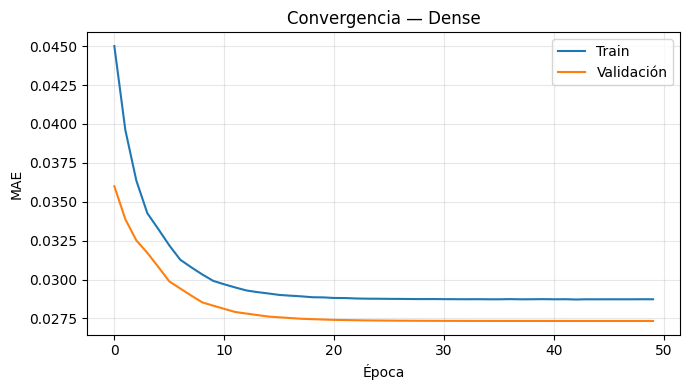

In [16]:
graficar_convergencia(hist_dense_4, 'Dense')
resultado_dense_4 = evaluar_modelo(modelo_dense_4, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_4)


{'modelo': 'Dense', 'mae_train': 0.010778562798367843, 'mae_val': 0.009214211673192819, 'mae_test': 0.01150607157695635, 'n_params': 182807}


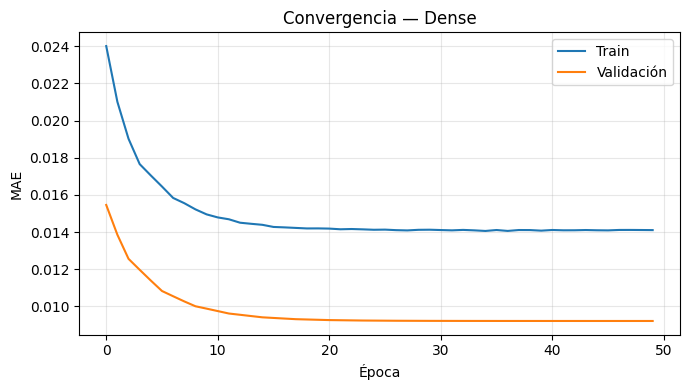

In [17]:
graficar_convergencia(hist_dense_5, 'Dense')
resultado_dense_5 = evaluar_modelo(modelo_dense_5, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_5)


{'modelo': 'Dense', 'mae_train': 0.007219064412897107, 'mae_val': 0.005906092140692016, 'mae_test': 0.007583925177016525, 'n_params': 35511}


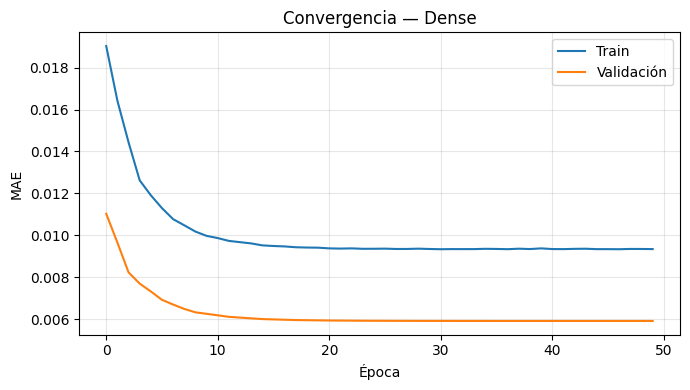

In [18]:
graficar_convergencia(hist_dense_6, 'Dense')
resultado_dense_6 = evaluar_modelo(modelo_dense_6, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_6)


In [19]:
base_cfg = {
    "epochs": 75,
    "batch_size": 500,
    "lr": 1e-3,          # se aplica por recompilación runtime
    "factor": 0.5,
    "rlr_patience": 3,
    "min_delta": 1e-5,
    "min_lr": 1e-6,
    "seed": 42,
    "verbose": 0 # Para evitar imprimir cada epoch durante el tuning
}

search_steps = [
    ("lr", [1e-3, 5e-4, 3e-4, 1e-4]),
    ("batch_size", [250, 1000, 5000, 10000, 14000]),
    ("factor", [0.3, 0.5, 0.7]),
    ("rlr_patience", [2, 3, 5]),
    ("min_delta", [1e-6, 1e-5, 1e-4]),
    ("min_lr", [1e-6, 1e-5, 1e-4]),
    ("epochs", [30, 50, 80, 100])
]



lr           -> mejor: 0.0003 | score=0.004302 | val_loss=0.004302 | gap=0.001136 (epoca 6)
batch_size   -> mejor: 500 | score=0.004302 | val_loss=0.004302 | gap=0.001136 (epoca 6)
factor       -> mejor: 0.5 | score=0.004302 | val_loss=0.004302 | gap=0.001136 (epoca 6)
rlr_patience -> mejor: 3 | score=0.004302 | val_loss=0.004302 | gap=0.001136 (epoca 6)
min_delta    -> mejor: 1e-05 | score=0.004302 | val_loss=0.004302 | gap=0.001136 (epoca 6)
min_lr       -> mejor: 1e-06 | score=0.004302 | val_loss=0.004302 | gap=0.001136 (epoca 6)
epochs       -> mejor: 75 | score=0.004302 | val_loss=0.004302 | gap=0.001136 (epoca 6)
Mejor configuracion Dense_v2 OFAT:
{'epochs': 75, 'batch_size': 500, 'lr': 0.0003, 'factor': 0.5, 'rlr_patience': 3, 'min_delta': 1e-05, 'min_lr': 1e-06, 'seed': 42, 'verbose': 0}
Mejor val_loss: 0.004302 en epoca 6


,param,value,score,best_val_loss,best_train_loss,train_val_gap,best_epoch,epochs,batch_size,lr,factor,rlr_patience,min_delta,min_lr,seed,verbose
0,lr,0.0003,0.004302,0.004302,0.005438,0.001136,6,75,500,0.0003,0.5,3,0.000010,0.000001,42,0
1,factor,0.5,0.004302,0.004302,0.005438,0.001136,6,75,500,0.0003,0.5,3,0.000010,0.000001,42,0
2,rlr_patience,3,0.004302,0.004302,0.005438,0.001136,6,75,500,0.0003,0.5,3,0.000010,0.000001,42,0
3,epochs,30,0.004302,0.004302,0.005438,0.001136,6,30,500,0.0003,0.5,3,0.000010,0.000001,42,0
4,min_lr,0.00001,0.004302,0.004302,0.005438,0.001136,6,75,500,0.0003,0.5,3,0.000010,0.000010,42,0
5,min_lr,0.000001,0.004302,0.004302,0.005438,0.001136,6,75,500,0.0003,0.5,3,0.000010,0.000001,42,0
6,min_delta,0.0001,0.004302,0.004302,0.005438,0.001136,6,75,500,0.0003,0.5,3,0.000100,0.000001,42,0
7,epochs,100,0.004302,0.004302,0.005438,0.001136,6,100,500,0.0003,0.5,3,0.000010,0.000001,42,0
8,epochs,80,0.004302,0.004302,0.005438,0.001136,6,80,500,0.0003,0.5,3,0.000010,0.000001,42,0
9,epochs,50,0.004302,0.004302,0.005438,0.001136,6,50,500,0.0003,0.5,3,0.000010,0.000001,42,0


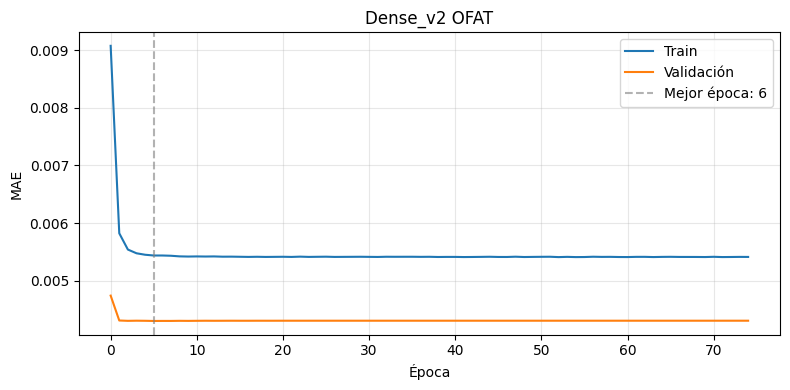

{'modelo': 'construir_dense_v2_ofat', 'mae_train': 0.005394167592181638, 'mae_val': 0.0043067468394359775, 'mae_test': 0.005590747111049165, 'n_params': 99543, 'funcion': 'construir_dense_v2', 'best_val_loss': 0.0043022893369197845, 'best_epoch': 6, 'best_cfg': {'epochs': 75, 'batch_size': 500, 'lr': 0.0003, 'factor': 0.5, 'rlr_patience': 3, 'min_delta': 1e-05, 'min_lr': 1e-06, 'seed': 42, 'verbose': 0}}


In [20]:
# Dense_v2 ya es la arquitectura elegida: optimizamos solo este modelo.
best_cfg, best_val, best_epoch, best_hist, best_model, df_trials = ofat_search(
    model_fn_name='construir_dense_v2',
    base_cfg=base_cfg.copy(),
    search_steps=search_steps,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
)

resultado_dense_v2_ofat = evaluar_modelo(
    best_model,
    X_train_plano, y_train,
    X_val_plano, y_val,
    X_test_plano, y_test,
    nombre='construir_dense_v2_ofat',
)
resultado_dense_v2_ofat.update({
    'funcion': 'construir_dense_v2',
    'best_val_loss': best_val,
    'best_epoch': best_epoch,
    'best_cfg': best_cfg,
})

print('Mejor configuracion Dense_v2 OFAT:')
print(best_cfg)
print(f'Mejor val_loss: {best_val:.6f} en epoca {best_epoch}')
display(df_trials.head(15))
plot_best_history(best_hist, 'Dense_v2 OFAT')
print(resultado_dense_v2_ofat)

# Resultado Dense activo hasta que el halving/refinamiento lo mejore.
resultado_dense = resultado_dense_v2_ofat


## 1.3.1 Tuning Dense_v2 con successive halving


Ronda corta: 24/384 candidatos con 20 epocas


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


construir_dense_v2: 1/24 candidatos cortos | mejor score=0.004302
construir_dense_v2: 6/24 candidatos cortos | mejor score=0.004298
construir_dense_v2: 12/24 candidatos cortos | mejor score=0.004298
construir_dense_v2: 18/24 candidatos cortos | mejor score=0.004298
construir_dense_v2: 24/24 candidatos cortos | mejor score=0.004298
Ronda final: 6 candidatos con 150 epocas


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


final 1/6 | mejor score=0.004298 | val_loss=0.004298
final 2/6 | mejor score=0.004298 | val_loss=0.004298
final 3/6 | mejor score=0.004298 | val_loss=0.004298
final 4/6 | mejor score=0.004298 | val_loss=0.004298
final 5/6 | mejor score=0.004298 | val_loss=0.004298
final 6/6 | mejor score=0.004298 | val_loss=0.004298
Mejor configuracion Dense_v2 halving:
{'epochs': 150, 'batch_size': 256, 'lr': 0.0005, 'factor': 0.5, 'rlr_patience': 5, 'min_delta': 1e-06, 'min_lr': 1e-06, 'seed': 42, 'verbose': 0, 'es_patience': 25, 'restore_best_weights': True}
Mejor val_loss: 0.004298 en epoca 8


,trial,score,best_val_loss,best_train_loss,train_val_gap,best_epoch,epochs,batch_size,lr,factor,rlr_patience,min_delta,min_lr,seed,verbose,es_patience,restore_best_weights
0,4,0.004298,0.004298,0.005404,0.001105,8,20,256,0.00050,0.5,5,0.000001,1.000000e-06,42,0,25,True
1,5,0.004298,0.004298,0.005404,0.001105,8,20,256,0.00050,0.7,8,0.000001,1.000000e-07,42,0,25,True
2,9,0.004301,0.004301,0.005398,0.001097,16,20,128,0.00030,0.7,5,0.000001,1.000000e-06,42,0,25,True
3,13,0.004302,0.004302,0.005399,0.001098,15,20,64,0.00010,0.5,8,0.000001,1.000000e-06,42,0,25,True
4,3,0.004302,0.004302,0.005396,0.001095,19,20,128,0.00050,0.5,8,0.000005,1.000000e-06,42,0,25,True
5,14,0.004302,0.004302,0.005422,0.001120,8,20,128,0.00010,0.5,5,0.000001,1.000000e-07,42,0,25,True
6,12,0.004302,0.004302,0.005417,0.001115,11,20,512,0.00030,0.7,5,0.000005,1.000000e-06,42,0,25,True
7,19,0.004302,0.004302,0.005442,0.001140,7,20,64,0.00005,0.5,8,0.000010,1.000000e-06,42,0,25,True
8,1,0.004302,0.004302,0.005396,0.001094,18,20,64,0.00050,0.5,5,0.000001,1.000000e-07,42,0,25,True
9,7,0.004303,0.004303,0.005396,0.001093,18,20,64,0.00030,0.5,5,0.000005,1.000000e-06,42,0,25,True


,trial,score,best_val_loss,best_train_loss,train_val_gap,best_epoch,epochs,batch_size,lr,factor,rlr_patience,min_delta,min_lr,seed,verbose,es_patience,restore_best_weights
0,1,0.004298,0.004298,0.005404,0.001105,8,150,256,0.0005,0.5,5,0.000001,1.000000e-06,42,0,25,True
1,2,0.004298,0.004298,0.005404,0.001105,8,150,256,0.0005,0.7,8,0.000001,1.000000e-07,42,0,25,True
2,3,0.004301,0.004301,0.005398,0.001097,16,150,128,0.0003,0.7,5,0.000001,1.000000e-06,42,0,25,True
3,5,0.004301,0.004301,0.005397,0.001096,22,150,128,0.0005,0.5,8,0.000005,1.000000e-06,42,0,25,True
4,4,0.004302,0.004302,0.005399,0.001098,15,150,64,0.0001,0.5,8,0.000001,1.000000e-06,42,0,25,True
5,6,0.004302,0.004302,0.005422,0.001120,8,150,128,0.0001,0.5,5,0.000001,1.000000e-07,42,0,25,True


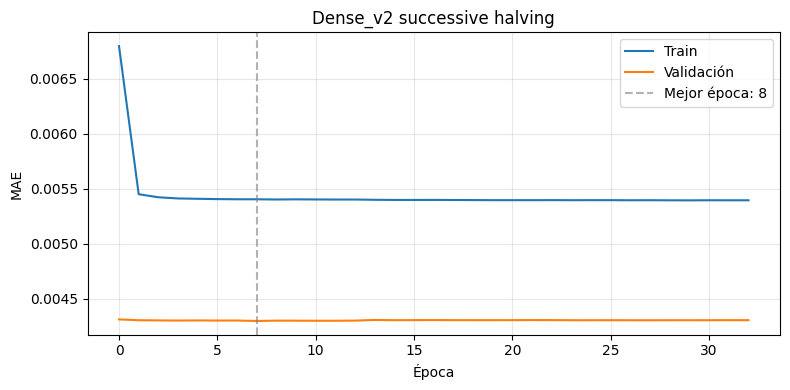

{'modelo': 'construir_dense_v2_halving', 'mae_train': 0.005399185046230015, 'mae_val': 0.0042984156116273224, 'mae_test': 0.005587774042741964, 'n_params': 99543, 'funcion': 'construir_dense_v2', 'best_val_loss': 0.0042984155006706715, 'best_epoch': 8, 'best_cfg': {'epochs': 150, 'batch_size': 256, 'lr': 0.0005, 'factor': 0.5, 'rlr_patience': 5, 'min_delta': 1e-06, 'min_lr': 1e-06, 'seed': 42, 'verbose': 0, 'es_patience': 25, 'restore_best_weights': True}}


In [21]:
# Successive halving solo para Dense_v2.
base_cfg_dense_halving = base_cfg.copy()
base_cfg_dense_halving.update({
    'epochs': 150,
    'batch_size': 128,
    'lr': 3e-4,
    'factor': 0.5,
    'rlr_patience': 6,
    'min_delta': 1e-6,
    'min_lr': 1e-7,
    'es_patience': 25,
    'restore_best_weights': True,
    'verbose': 0,
})

search_steps_dense_halving = [
    ('lr', [5e-4, 3e-4, 1e-4, 5e-5]),
    ('batch_size', [64, 128, 256, 512]),
    ('factor', [0.5, 0.7]),
    ('rlr_patience', [5, 8]),
    ('min_delta', [1e-6, 5e-6, 1e-5]),
    ('min_lr', [1e-7, 1e-6]),
]

best_cfg_dense_halving, best_val_dense_halving, best_epoch_dense_halving, best_hist_dense_halving, best_model_dense_halving, df_dense_short, df_dense_final = successive_halving_search(
    'construir_dense_v2',
    base_cfg_dense_halving,
    search_steps_dense_halving,
    X_train, y_train,
    X_val, y_val,
    n_candidates=24,
    keep_top=6,
    short_epochs=20,
    final_epochs=150,
)

resultado_dense_halving = evaluar_modelo(
    best_model_dense_halving,
    X_train_plano, y_train,
    X_val_plano, y_val,
    X_test_plano, y_test,
    nombre='construir_dense_v2_halving',
)
resultado_dense_halving.update({
    'funcion': 'construir_dense_v2',
    'best_val_loss': best_val_dense_halving,
    'best_epoch': best_epoch_dense_halving,
    'best_cfg': best_cfg_dense_halving,
})

print('Mejor configuracion Dense_v2 halving:')
print(best_cfg_dense_halving)
print(f'Mejor val_loss: {best_val_dense_halving:.6f} en epoca {best_epoch_dense_halving}')
display(df_dense_short.head(10))
display(df_dense_final)

if best_epoch_dense_halving == len(best_hist_dense_halving.history['val_loss']):
    print('Aviso: la mejor validacion fue en la ultima epoca; puedes subir final_epochs si la curva sigue bajando.')

plot_best_history(best_hist_dense_halving, 'Dense_v2 successive halving')
print(resultado_dense_halving)

resultado_dense = resultado_dense_halving


## 1.3.2 Refinamiento final de Dense_v2


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 462: ReduceLROnPlateau reducing learning rate to 1.6999999570543877e-05.


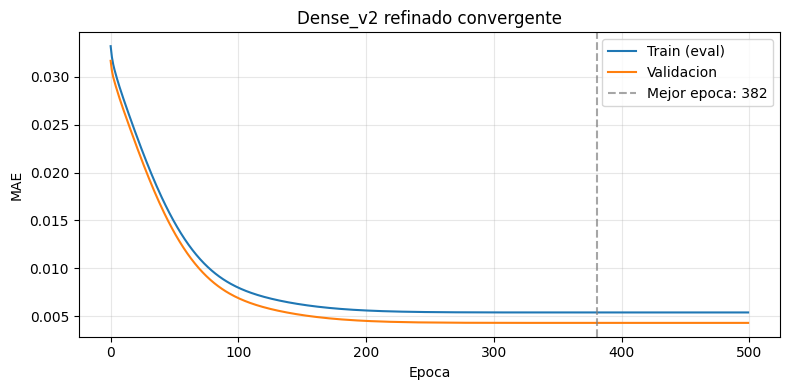

,origen_variable,modelo,mae_train,mae_val,mae_test,n_params
0,resultado_dense_convergente,Dense_v2_convergente_largo,0.005394,0.004306,0.005585,72743
1,resultado_dense_halving,construir_dense_v2_halving,0.005399,0.004298,0.005588,99543
2,resultado_dense_v2_ofat,construir_dense_v2_ofat,0.005394,0.004307,0.005591,99543


resultado_dense elegido como mejor Dense_v2 optimizado:
{'modelo': 'Dense_v2_convergente_largo', 'mae_train': 0.005394325378374401, 'mae_val': 0.004305526088864214, 'mae_test': 0.005585136362372567, 'n_params': 72743, 'funcion': 'construir_dense_v2', 'best_val_loss': 0.004305157344788313, 'best_epoch': 382, 'best_cfg': nan, 'gap_train_val': 0.0010887992895101872, 'best_train_eval_loss': 0.005394370295107365, 'best_train_val_gap': 0.0010892129503190517}


In [22]:
# Refinamiento final solo de Dense_v2.
# No compara contra otras arquitecturas; parte del mejor Dense_v2 halving si existe.
class TrainEvalLoss(keras.callbacks.Callback):
    def __init__(self, X, y, batch_size=256):
        super().__init__()
        self.X = X
        self.y = y
        self.batch_size = batch_size

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['train_eval_loss'] = self.model.evaluate(
            self.X, self.y, batch_size=self.batch_size, verbose=0
        )

keras.backend.clear_session()
keras.utils.set_random_seed(42)

modelo_dense_convergente = modelos_mod.construir_dense_v2_param(
    dim_entrada=X_train_plano.shape[1],
    dim_salida=y_train.shape[1],
    units=(96, 48, 24),
    dropout=0.25,
    activation='relu',
    l2=1e-4,
)
modelo_dense_convergente.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5, clipnorm=1.0),
    loss='mae',
)

hist_dense_convergente = modelo_dense_convergente.fit(
    X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=500,
    batch_size=256,
    callbacks=[
        TrainEvalLoss(X_train_plano, y_train, batch_size=256),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.85,
            patience=80,
            min_delta=1e-8,
            min_lr=1e-7,
            verbose=1,
        ),
    ],
    verbose=0,
)

hist = hist_dense_convergente.history
train_curve = np.array(hist['train_eval_loss'])
val_curve = np.array(hist['val_loss'])
gap_curve = np.abs(train_curve - val_curve)

inicio_zona_plana = int(len(val_curve) * 0.65)
score = val_curve + 0.5 * gap_curve
best_idx = inicio_zona_plana + int(np.argmin(score[inicio_zona_plana:]))

resultado_dense_convergente = evaluar_modelo(
    modelo_dense_convergente,
    X_train_plano, y_train,
    X_val_plano, y_val,
    X_test_plano, y_test,
    nombre='Dense_v2_convergente_largo',
)
resultado_dense_convergente.update({
    'funcion': 'construir_dense_v2',
    'gap_train_val': abs(resultado_dense_convergente['mae_train'] - resultado_dense_convergente['mae_val']),
    'best_epoch': best_idx + 1,
    'best_val_loss': float(val_curve[best_idx]),
    'best_train_eval_loss': float(train_curve[best_idx]),
    'best_train_val_gap': float(gap_curve[best_idx]),
})

plt.figure(figsize=(8, 4))
plt.plot(train_curve, label='Train (eval)')
plt.plot(val_curve, label='Validacion')
plt.axvline(best_idx, color='gray', ls='--', alpha=0.7, label=f'Mejor epoca: {best_idx + 1}')
plt.title('Dense_v2 refinado convergente')
plt.xlabel('Epoca')
plt.ylabel('MAE')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Seleccion final solo entre resultados Dense_v2 optimizados.
candidatos_dense_v2 = []
for nombre_var in ['resultado_dense_v2_ofat', 'resultado_dense_halving', 'resultado_dense_convergente']:
    if nombre_var in globals():
        candidato = globals()[nombre_var].copy()
        candidato['origen_variable'] = nombre_var
        candidatos_dense_v2.append(candidato)

if not candidatos_dense_v2:
    raise RuntimeError('No hay resultados Dense_v2 calculados para seleccionar resultado_dense.')

df_resultados_dense_v2 = pd.DataFrame(candidatos_dense_v2).sort_values(
    ['mae_test', 'mae_val', 'mae_train']
).reset_index(drop=True)

display(df_resultados_dense_v2[[
    'origen_variable', 'modelo', 'mae_train', 'mae_val', 'mae_test', 'n_params'
]])

resultado_dense = df_resultados_dense_v2.loc[0].drop(labels=['origen_variable']).to_dict()
print('resultado_dense elegido como mejor Dense_v2 optimizado:')
print(resultado_dense)


## 1.4 Modelo Recurrente (LSTM)


In [23]:
modelo_lstm = construir_recurrente(X_train.shape[1:], y_train.shape[1])
modelo_lstm.summary()
hist_lstm = modelo_lstm.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,023 (93.84 KB)

 Trainable params: 24,023 (93.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0056 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0055 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 3/100
210/216 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0054
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0054 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0054 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 6/100
213/216 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0054
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0054 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - los

{'modelo': 'LSTM', 'mae_train': 0.005332333533266805, 'mae_val': 0.0043360996139332995, 'mae_test': 0.005617175549773178, 'n_params': 24023}


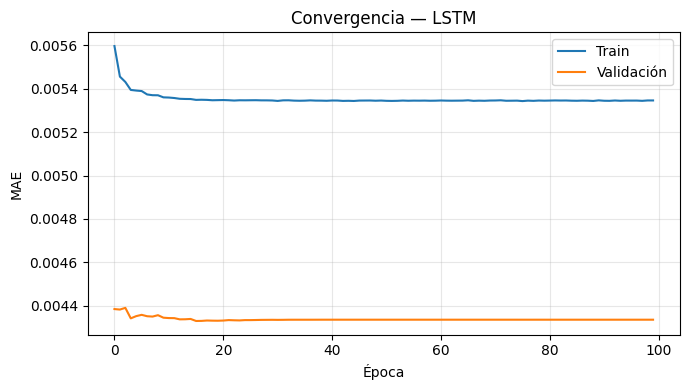

In [24]:
graficar_convergencia(hist_lstm, 'LSTM')
resultado_lstm = evaluar_modelo(modelo_lstm, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM')
print(resultado_lstm)


## 1.4.1 Refinamiento de LSTM parametrizable



Candidato 1/3: lstm16_lr2e-5_do45_l2_1e-4_gap_fuerte
{'mae_train': 0.005385738939082778, 'mae_val': 0.004304613046906623, 'mae_test': 0.0055827582555518585, 'gap_train_val': 0.0010811258921761546, 'gap_train_test': 0.00019701931646908064, 'best_train_val_gap': 0.0010812049731612206, 'best_epoch': 450, 'balanced_score': 0.016983468208462}

Candidato 2/3: lstm16_lr1e-5_do45_l2_1e-4_gap_fuerte
{'mae_train': 0.005386006360186501, 'mae_val': 0.004305392245315557, 'mae_test': 0.0055830792577106995, 'gap_train_val': 0.001080614114870944, 'gap_train_test': 0.00019707289752419858, 'best_train_val_gap': 0.001080840826034546, 'best_epoch': 600, 'balanced_score': 0.019295952616631987}

Candidato 3/3: lstm16_lr2e-5_b512_do35_l2_2e-4
{'mae_train': 0.00538819251673728, 'mae_val': 0.004306407593535863, 'mae_test': 0.005583588642225196, 'gap_train_val': 0.001081784923201417, 'gap_train_test': 0.00019539612548791652, 'best_train_val_gap': 0.0010817842558026314, 'best_epoch': 500, 'balanced_score': 0.01

,modelo,mae_train,mae_val,mae_test,gap_train_val,gap_train_test,best_train_val_gap,best_epoch,balanced_score,n_params
0,lstm16_lr1e-5_do45_l2_1e-4_gap_fuerte,0.005386,0.004305,0.005583,0.001081,0.000197,0.001081,600,0.019296,2951
1,lstm16_lr2e-5_do45_l2_1e-4_gap_fuerte,0.005386,0.004305,0.005583,0.001081,0.000197,0.001081,450,0.016983,2951
2,lstm16_lr2e-5_b512_do35_l2_2e-4,0.005388,0.004306,0.005584,0.001082,0.000195,0.001082,500,0.018644,2951


LSTM balanceado elegido: lstm16_lr1e-5_do45_l2_1e-4_gap_fuerte
Configuracion elegida: {'units': 16, 'recurrent_dropout': 0.0, 'verbose': 0, 'seed': 42, 'track_train_eval': True, 'train_eval_samples': None, 'gap_metric': 'train_eval_loss', 'es_monitor': 'balanced_score', 'rlr_monitor': 'balanced_score', 'restore_best_weights': True, 'lr': 1e-05, 'batch_size': 256, 'dropout': 0.45, 'l2': 0.0001, 'epochs': 600, 'es_patience': 160, 'factor': 0.92, 'rlr_patience': 60, 'min_lr': 5e-07, 'gap_target': 7.5e-05, 'gap_weight': 2.0, 'gap_excess_weight': 12.0, 'clipnorm': 0.5}
Mejor epoca balanceada: 600
val_loss: 0.00506418
train_eval_loss: 0.00614502
gap en mejor epoca: 0.00108084


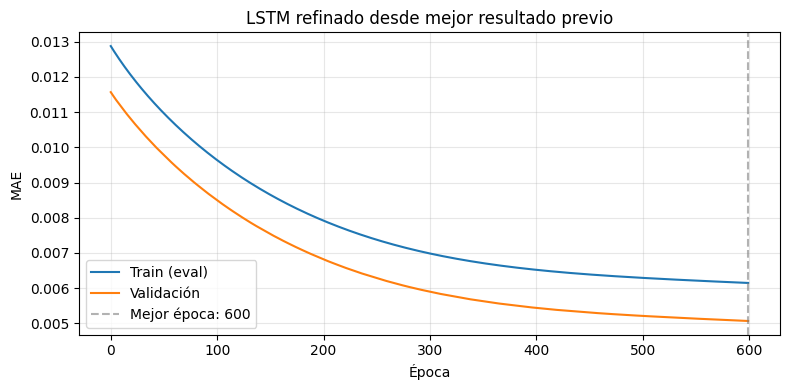

{'modelo': 'LSTM_param_halving_refinado_balanceado', 'mae_train': 0.005386006360186501, 'mae_val': 0.004305392245315557, 'mae_test': 0.0055830792577106995, 'n_params': 2951, 'gap_train_val': 0.001080614114870944, 'gap_train_test': 0.00019707289752419858, 'balanced_score': 0.019295952616631987, 'best_val_loss': 0.005064181052148342, 'best_train_eval_loss': 0.006145021878182888, 'best_train_val_gap': 0.001080840826034546, 'best_epoch': 600}


In [25]:
# Continuacion corta desde el LSTM base de ent30_sal05:
# Se parte del LSTM base calculado arriba para esta ventana.
# Esta celda NO repite un halving grande: prueba pocos candidatos LSTM mas pequenos/regularizados.

# Ajusta esto si quieres hacerlo aun mas rapido. Con 3 candidatos suele bastar para iterar.
MAX_CANDIDATOS = 3

candidatos_lstm_balanceados = [
    # Mas lento y mas regularizado: deberia quitar la caida vertical y acercar curvas.
    dict(nombre='lstm16_lr2e-5_do45_l2_1e-4_gap_fuerte', lr=2e-5, batch_size=256,
         dropout=0.45, l2=1e-4, epochs=450, es_patience=120,
         factor=0.90, rlr_patience=45, min_lr=1e-6,
         gap_target=7.5e-5, gap_weight=2.0, gap_excess_weight=10.0, clipnorm=0.5),
    # Muy lento: curva mas gradual; util si la anterior aun baja en vertical.
    dict(nombre='lstm16_lr1e-5_do45_l2_1e-4_gap_fuerte', lr=1e-5, batch_size=256,
         dropout=0.45, l2=1e-4, epochs=600, es_patience=160,
         factor=0.92, rlr_patience=60, min_lr=5e-7,
         gap_target=7.5e-5, gap_weight=2.0, gap_excess_weight=12.0, clipnorm=0.5),
    # Batch grande suaviza pasos de optimizacion y evita saltos bruscos.
    dict(nombre='lstm16_lr2e-5_b512_do35_l2_2e-4', lr=2e-5, batch_size=512,
         dropout=0.35, l2=2e-4, epochs=500, es_patience=140,
         factor=0.90, rlr_patience=50, min_lr=1e-6,
         gap_target=1e-4, gap_weight=2.5, gap_excess_weight=10.0, clipnorm=0.25),
    # Algo menos dropout para intentar bajar train sin despegar validacion.
    dict(nombre='lstm16_lr2e-5_do30_l2_1e-4', lr=2e-5, batch_size=256,
         dropout=0.30, l2=1e-4, epochs=450, es_patience=120,
         factor=0.90, rlr_patience=45, min_lr=1e-6,
         gap_target=1e-4, gap_weight=2.0, gap_excess_weight=8.0, clipnorm=0.5),
    # Capacidad menor: puede reducir la distancia si el modelo de 16 aun aprende demasiado rapido.
    dict(nombre='lstm12_lr2e-5_do35_l2_1e-4', units=12, lr=2e-5, batch_size=256,
         dropout=0.35, l2=1e-4, epochs=500, es_patience=140,
         factor=0.90, rlr_patience=50, min_lr=1e-6,
         gap_target=1e-4, gap_weight=2.0, gap_excess_weight=8.0, clipnorm=0.5),
]

base_comun = dict(
    units=16,
    recurrent_dropout=0.0,
    verbose=0,
    seed=42,
    track_train_eval=True,
    train_eval_samples=None,
    gap_metric='train_eval_loss',
    es_monitor='balanced_score',
    rlr_monitor='balanced_score',
    restore_best_weights=True,
)

resultados_lstm_balanceados = []
historias_lstm_balanceadas = {}
modelos_lstm_balanceados = {}

for i, candidato in enumerate(candidatos_lstm_balanceados[:MAX_CANDIDATOS], start=1):
    cfg = {**base_comun, **candidato}
    nombre = cfg.pop('nombre')
    print(f"\nCandidato {i}/{min(MAX_CANDIDATOS, len(candidatos_lstm_balanceados))}: {nombre}")

    score, best_val, best_epoch, best_train, best_gap, hist, model = modelos_mod._train_one(
        'construir_lstm_param', cfg, X_train, y_train, X_val, y_val
    )

    met = evaluar_modelo(
        model, X_train, y_train,
        X_val, y_val, X_test, y_test,
        nombre=nombre,
    )
    met['gap_train_val'] = abs(met['mae_train'] - met['mae_val'])
    met['gap_train_test'] = abs(met['mae_train'] - met['mae_test'])
    met['balanced_score'] = score
    met['best_val_loss'] = best_val
    met['best_train_eval_loss'] = best_train
    met['best_train_val_gap'] = best_gap
    met['best_epoch'] = best_epoch
    met['cfg'] = cfg

    resultados_lstm_balanceados.append(met)
    historias_lstm_balanceadas[nombre] = hist
    modelos_lstm_balanceados[nombre] = model

    print({k: met[k] for k in [
        'mae_train', 'mae_val', 'mae_test', 'gap_train_val',
        'gap_train_test', 'best_train_val_gap', 'best_epoch', 'balanced_score'
    ]})

# Seleccion: primero curvas casi juntas en la mejor epoca, despues test/val.
df_lstm_balanceados = pd.DataFrame(resultados_lstm_balanceados)
df_lstm_balanceados = df_lstm_balanceados.sort_values(
    ['best_train_val_gap', 'gap_train_val', 'mae_test', 'balanced_score']
).reset_index(drop=True)
display(df_lstm_balanceados[[
    'modelo', 'mae_train', 'mae_val', 'mae_test', 'gap_train_val',
    'gap_train_test', 'best_train_val_gap', 'best_epoch', 'balanced_score', 'n_params'
]])

mejor_nombre_lstm_balanceado = df_lstm_balanceados.loc[0, 'modelo']
best_hist_lstm_refinado = historias_lstm_balanceadas[mejor_nombre_lstm_balanceado]
best_model_lstm_refinado = modelos_lstm_balanceados[mejor_nombre_lstm_balanceado]
resultado_lstm_refinado = df_lstm_balanceados.loc[0].drop(labels=['cfg']).to_dict()
resultado_lstm_refinado['modelo'] = 'LSTM_param_halving_refinado_balanceado'

historia = best_hist_lstm_refinado.history
idx = int(np.argmin(historia['balanced_score']))
print('LSTM balanceado elegido:', mejor_nombre_lstm_balanceado)
print('Configuracion elegida:', df_lstm_balanceados.loc[0, 'cfg'])
print(f"Mejor epoca balanceada: {idx + 1}")
print(f"val_loss: {historia['val_loss'][idx]:.8f}")
print(f"train_eval_loss: {historia['train_eval_loss'][idx]:.8f}")
print(f"gap en mejor epoca: {historia['train_val_gap'][idx]:.8f}")

plot_best_history(best_hist_lstm_refinado, 'LSTM refinado desde mejor resultado previo')
print(resultado_lstm_refinado)

# Usar este LSTM en el resumen de competicion si ejecutas la celda final.
resultado_lstm = resultado_lstm_refinado


### 1.4.2 Entrenamiento largo del mejor LSTM balanceado

Continua el mejor LSTM refinado con muchas mas epocas y learning rate bajo hasta que las curvas queden casi planas.


Configuracion base LSTM elegida en la celda anterior:
{'units': 16, 'recurrent_dropout': 0.0, 'verbose': 0, 'seed': 42, 'track_train_eval': True, 'train_eval_samples': None, 'gap_metric': 'train_eval_loss', 'es_monitor': 'balanced_score', 'rlr_monitor': 'balanced_score', 'restore_best_weights': True, 'lr': 1e-05, 'batch_size': 256, 'dropout': 0.45, 'l2': 0.0001, 'epochs': 600, 'es_patience': 160, 'factor': 0.92, 'rlr_patience': 60, 'min_lr': 5e-07, 'gap_target': 7.5e-05, 'gap_weight': 2.0, 'gap_excess_weight': 12.0, 'clipnorm': 0.5}
Entrenando LSTM largo: misma_config_mas_epocas


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando LSTM largo: mas_dropout_l2
Entrenando LSTM largo: lr_menor_mas_l2


,modelo,mae_train,mae_val,mae_test,gap_train_val,gap_train_test,best_train_val_gap,best_epoch,balanced_score,n_params
0,misma_config_mas_epocas,0.005385,0.004306,0.005585,0.001079,0.000200,0.001079,1908,0.018508,2951
1,mas_dropout_l2,0.005388,0.004305,0.005585,0.001083,0.000197,0.001083,1969,0.019649,2951
2,lr_menor_mas_l2,0.005389,0.004305,0.005584,0.001084,0.000196,0.001084,2000,0.022722,2951


Mejor LSTM largo: misma_config_mas_epocas
Configuracion elegida: {'units': 16, 'recurrent_dropout': 0.0, 'verbose': 0, 'seed': 42, 'track_train_eval': True, 'train_eval_samples': None, 'gap_metric': 'train_eval_loss', 'es_monitor': 'balanced_score', 'rlr_monitor': 'balanced_score', 'restore_best_weights': True, 'lr': 1e-05, 'batch_size': 256, 'dropout': 0.45, 'l2': 0.0001, 'epochs': 2000, 'es_patience': 260, 'factor': 0.92, 'rlr_patience': 70, 'min_lr': 5e-07, 'gap_target': 7.5e-05, 'gap_weight': 2.0, 'gap_excess_weight': 12.0, 'clipnorm': 0.5}
{'modelo': 'LSTM_param_refinado_largo_balanceado', 'mae_train': 0.005385029175017509, 'mae_val': 0.004306207107628227, 'mae_test': 0.005584673228264494, 'n_params': 2951, 'gap_train_val': 0.0010788220673892818, 'gap_train_test': 0.0001996440532469855, 'best_epoch': 1908, 'best_train_eval_loss': 0.005387560464441776, 'best_val_loss': 0.004309037700295448, 'best_train_val_gap': 0.001078522764146328, 'balanced_score': 0.018508356398344042}


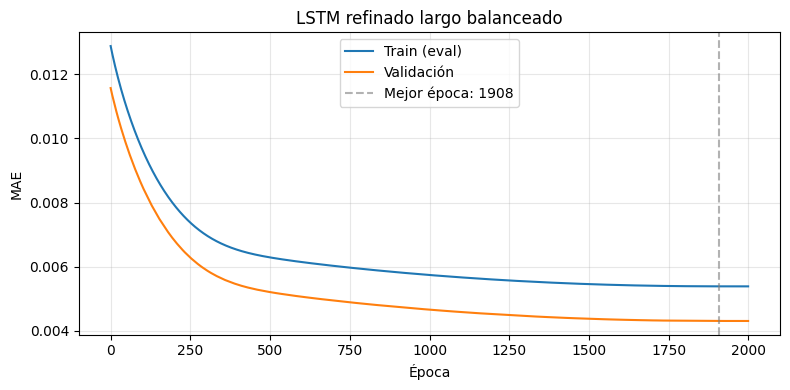

In [42]:
# Continuacion del mejor LSTM refinado.
# Parte de la mejor configuracion encontrada en la celda anterior y prueba pocas
# variantes mas largas/regularizadas para cerrar el espacio entre train y validacion.

cfg_base_lstm = df_lstm_balanceados.loc[0, 'cfg'].copy()
print('Configuracion base LSTM elegida en la celda anterior:')
print(cfg_base_lstm)

candidatos_lstm_largo = [
    ('misma_config_mas_epocas', {}),
    ('mas_dropout_l2', {
        'dropout': min(cfg_base_lstm.get('dropout', 0.35) + 0.10, 0.60),
        'l2': max(cfg_base_lstm.get('l2', 1e-4) * 2, 2e-4),
        'gap_weight': 3.0,
        'gap_excess_weight': 12.0,
    }),
    ('lr_menor_mas_l2', {
        'lr': cfg_base_lstm.get('lr', 2e-5) * 0.5,
        'l2': max(cfg_base_lstm.get('l2', 1e-4) * 3, 3e-4),
        'gap_weight': 3.0,
        'gap_excess_weight': 14.0,
    }),
]

resultados_lstm_largo = []
historias_lstm_largo = {}
modelos_lstm_largo = {}

for nombre, cambios in candidatos_lstm_largo:
    cfg = cfg_base_lstm.copy()
    cfg.update(cambios)
    cfg.update({
        'epochs': 2000,
        'verbose': 0,
        'es_patience': 260,
        'restore_best_weights': True,
        'track_train_eval': True,
        'train_eval_samples': None,
        'gap_metric': 'train_eval_loss',
        'es_monitor': 'balanced_score',
        'rlr_monitor': 'balanced_score',
        'gap_target': min(cfg.get('gap_target', 1e-4), 7.5e-5),
        'min_lr': min(cfg.get('min_lr', 1e-6), 5e-7),
        'rlr_patience': max(cfg.get('rlr_patience', 45), 70),
        'factor': max(cfg.get('factor', 0.90), 0.90),
    })

    print(f'Entrenando LSTM largo: {nombre}')
    score, best_val, best_epoch, best_train, best_gap, hist, model = modelos_mod._train_one(
        'construir_lstm_param',
        cfg,
        X_train, y_train,
        X_val, y_val,
    )

    met = evaluar_modelo(
        model,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        nombre=nombre,
    )
    met['gap_train_val'] = abs(met['mae_train'] - met['mae_val'])
    met['gap_train_test'] = abs(met['mae_train'] - met['mae_test'])
    met['best_epoch'] = best_epoch
    met['best_train_eval_loss'] = best_train
    met['best_val_loss'] = best_val
    met['best_train_val_gap'] = best_gap
    met['balanced_score'] = score
    met['cfg'] = cfg

    resultados_lstm_largo.append(met)
    historias_lstm_largo[nombre] = hist
    modelos_lstm_largo[nombre] = model

df_lstm_largo = pd.DataFrame(resultados_lstm_largo).sort_values(
    ['best_train_val_gap', 'gap_train_val', 'mae_test']
).reset_index(drop=True)

display(df_lstm_largo[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'gap_train_val', 'gap_train_test', 'best_train_val_gap',
    'best_epoch', 'balanced_score', 'n_params'
]])

mejor_lstm_largo = df_lstm_largo.loc[0, 'modelo']
hist_lstm_largo = historias_lstm_largo[mejor_lstm_largo]
modelo_lstm_largo = modelos_lstm_largo[mejor_lstm_largo]
resultado_lstm_largo = df_lstm_largo.loc[0].drop(labels=['cfg']).to_dict()
resultado_lstm_largo['modelo'] = 'LSTM_param_refinado_largo_balanceado'

print('Mejor LSTM largo:', mejor_lstm_largo)
print('Configuracion elegida:', df_lstm_largo.loc[0, 'cfg'])
print(resultado_lstm_largo)

plot_best_history(hist_lstm_largo, 'LSTM refinado largo balanceado')

# Si esta curva es mejor que la del refinamiento corto, usa este resultado en competicion:
# resultado_lstm = resultado_lstm_largo


## 1.5 Modelo Conv1D


In [27]:
modelo_conv = construir_conv1d(X_train.shape[1:], y_train.shape[1])
modelo_conv.summary()
hist_conv = modelo_conv.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 28, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,415 (44.59 KB)

 Trainable params: 11,415 (44.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 3/100
211/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0054
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 7/100
209/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0053
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - los

{'modelo': 'Conv1D', 'mae_train': 0.0052056052485263205, 'mae_val': 0.00432129945189834, 'mae_test': 0.005578148000717601, 'n_params': 11415}


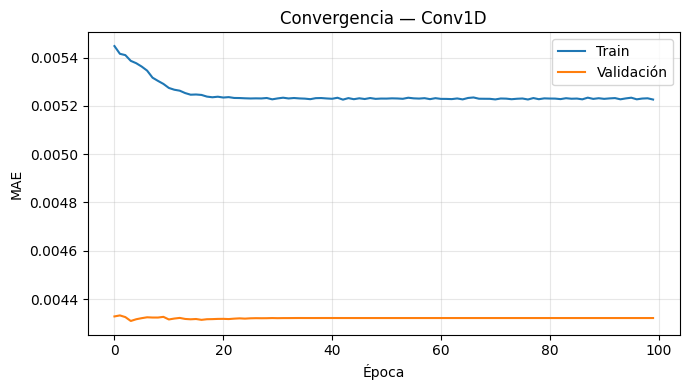

In [28]:
graficar_convergencia(hist_conv, 'Conv1D')
resultado_conv = evaluar_modelo(modelo_conv, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D')
print(resultado_conv)


### 1.5.1 Refinamiento Conv1D balanceado


Entrenando Conv1D_best_lr15e6...
Entrenando Conv1D_best_lr12e6...
Entrenando Conv1D_menos_reg_lr15e6...
Entrenando Conv1D_mas_suave_lr20e6...


,modelo,mae_train,mae_val,mae_test,gap_train_val,gap_train_test,best_train_val_gap,score_gap_final,best_epoch,n_params
0,Conv1D_best_lr15e6,0.005394,0.004306,0.005586,0.001088,0.000191,0.001088,0.002020,947,7415
1,Conv1D_best_lr12e6,0.005394,0.004306,0.005586,0.001088,0.000191,0.001088,0.002020,898,7415
2,Conv1D_mas_suave_lr20e6,0.005394,0.004306,0.005586,0.001088,0.000191,0.001088,0.002020,987,7415
3,Conv1D_menos_reg_lr15e6,0.005393,0.004304,0.005584,0.001089,0.000190,0.001089,0.002022,393,7415


Mejor Conv1D refinado: Conv1D_best_lr15e6
Configuracion elegida: {'filtros': 48, 'dropout': 0.2, 'l2': 3e-05, 'lr': 1.5e-05, 'epochs': 1000, 'batch_size': 256, 'factor': 0.9, 'rlr_patience': 80, 'min_delta': 1e-08, 'min_lr': 5e-07, 'es_patience': 220, 'restore_best_weights': True, 'seed': 42, 'clipnorm': 0.5, 'verbose': 0, 'track_train_eval': True, 'gap_metric': 'train_eval_loss', 'es_monitor': 'balanced_score', 'rlr_monitor': 'balanced_score', 'gap_target': 0.0001, 'gap_weight': 6.0, 'gap_excess_weight': 25.0}
{'modelo': 'Conv1D_param_refinado_balanceado', 'mae_train': 0.005394263426942109, 'mae_val': 0.004306275312550449, 'mae_test': 0.005585716245332783, 'n_params': 7415, 'gap_train_val': 0.00108798811439166, 'gap_train_test': 0.00019145281839067375, 'best_val_loss': 0.0043062749318778515, 'best_train_eval_loss': 0.005394263193011284, 'best_train_val_gap': 0.0010879882611334324, 'best_epoch': 947, 'balanced_score': 0.03553391102701425}


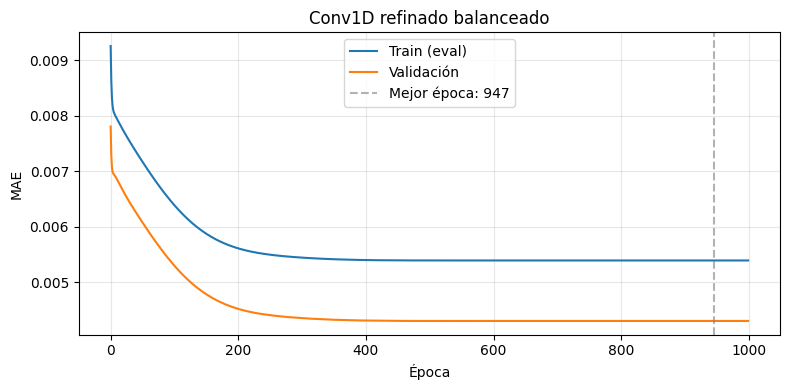

In [45]:
# Refinamiento Conv1D balanceado centrado en la mejor configuracion ya encontrada:
# filtros=48, dropout=0.20, l2=3e-5, lr=1e-5, epochs=900.
# Ajustamos el ritmo para evitar curvas demasiado planas o caidas verticales.

candidatos_conv = [
    {'nombre': 'Conv1D_best_lr15e6',      'filtros': 48, 'dropout': 0.20, 'l2': 3e-5, 'lr': 1.5e-5},
    {'nombre': 'Conv1D_best_lr12e6',      'filtros': 48, 'dropout': 0.20, 'l2': 3e-5, 'lr': 1.2e-5},
    {'nombre': 'Conv1D_menos_reg_lr15e6', 'filtros': 48, 'dropout': 0.15, 'l2': 1e-5, 'lr': 1.5e-5},
    {'nombre': 'Conv1D_mas_suave_lr20e6', 'filtros': 48, 'dropout': 0.25, 'l2': 5e-5, 'lr': 2.0e-5},
]

resultados_conv_balanceados = []
historias_conv_balanceadas = {}
modelos_conv_balanceados = {}

for candidato in candidatos_conv:
    nombre = candidato['nombre']
    cfg = {
        **candidato,
        'epochs': 1000,
        'batch_size': 256,
        'factor': 0.90,
        'rlr_patience': 80,
        'min_delta': 1e-8,
        'min_lr': 5e-7,
        'es_patience': 220,
        'restore_best_weights': True,
        'seed': 42,
        'clipnorm': 0.5,
        'verbose': 0,
        'track_train_eval': True,
        'gap_metric': 'train_eval_loss',
        'es_monitor': 'balanced_score',
        'rlr_monitor': 'balanced_score',
        'gap_target': 1e-4,
        'gap_weight': 6.0,
        'gap_excess_weight': 25.0,
    }
    cfg.pop('nombre')

    print(f'Entrenando {nombre}...')
    score, best_val, best_epoch, best_train, best_gap, hist, model = modelos_mod._train_one(
        'construir_conv1d_param', cfg, X_train, y_train, X_val, y_val
    )

    met = evaluar_modelo(model, X_train, y_train, X_val, y_val, X_test, y_test, nombre=nombre)
    met['gap_train_val'] = abs(met['mae_train'] - met['mae_val'])
    met['gap_train_test'] = abs(met['mae_train'] - met['mae_test'])
    met['best_val_loss'] = best_val
    met['best_train_eval_loss'] = best_train
    met['best_train_val_gap'] = best_gap
    met['best_epoch'] = best_epoch
    met['balanced_score'] = score
    met['cfg'] = cfg
    curva_loss = hist.history['val_loss']
    mejora_val = float(curva_loss[0] - min(curva_loss))
    penaliza_plana = 0.0005 if mejora_val < 2e-4 else 0.0
    penaliza_vertical = 0.0005 if best_epoch < int(cfg['epochs'] * 0.15) else 0.0
    met['score_gap_final'] = (
        met['best_train_val_gap']
        + 0.60 * met['gap_train_val']
        + 0.05 * met['mae_test']
        + penaliza_plana
        + penaliza_vertical
    )

    resultados_conv_balanceados.append(met)
    historias_conv_balanceadas[nombre] = hist
    modelos_conv_balanceados[nombre] = model

df_conv_balanceados = pd.DataFrame(resultados_conv_balanceados).sort_values(
    ['score_gap_final', 'best_train_val_gap', 'gap_train_val', 'mae_test']
).reset_index(drop=True)

display(df_conv_balanceados[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'gap_train_val', 'gap_train_test', 'best_train_val_gap',
    'score_gap_final', 'best_epoch', 'n_params'
]])

mejor_conv = df_conv_balanceados.loc[0, 'modelo']
modelo_conv_balanceado = modelos_conv_balanceados[mejor_conv]
hist_conv_balanceado = historias_conv_balanceadas[mejor_conv]
resultado_conv_balanceado = df_conv_balanceados.loc[0].drop(labels=['cfg', 'score_gap_final']).to_dict()
resultado_conv_balanceado['modelo'] = 'Conv1D_param_refinado_balanceado'

print('Mejor Conv1D refinado:', mejor_conv)
print('Configuracion elegida:', df_conv_balanceados.loc[0, 'cfg'])
print(resultado_conv_balanceado)
plot_best_history(hist_conv_balanceado, 'Conv1D refinado balanceado')


## 1.6 Modelo Mixto (Conv1D + LSTM)


In [31]:
modelo_mixto = construir_mixto(X_train.shape[1:], y_train.shape[1])
modelo_mixto.summary()
hist_mixto = modelo_mixto.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)


Model: "Mixto"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,999 (152.34 KB)

 Trainable params: 38,999 (152.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0055 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0054 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 3/100
209/216 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0054
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0054 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0053 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 6/100
214/216 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0052
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0052 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - 

{'modelo': 'Mixto', 'mae_train': 0.0047798401719752045, 'mae_val': 0.004708658268558835, 'mae_test': 0.0063203875455959, 'n_params': 38999}


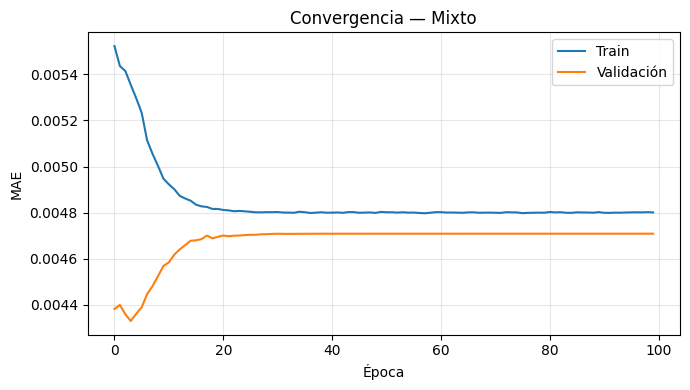

In [32]:
graficar_convergencia(hist_mixto, 'Mixto')
resultado_mixto = evaluar_modelo(modelo_mixto, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Mixto')
print(resultado_mixto)


### 1.6.1 Refinamiento Mixto balanceado


Entrenando Mixto_24_16_reg...
Entrenando Mixto_16_12_reg...
Entrenando Mixto_24_12_reg_fuerte...


,modelo,mae_train,mae_val,mae_test,gap_train_val,gap_train_test,best_train_val_gap,best_epoch,n_params
0,Mixto_16_12_reg,0.005394,0.004306,0.005585,0.001088,0.000191,0.001088,973,2811
1,Mixto_24_16_reg,0.005394,0.004306,0.005585,0.001089,0.000191,0.001089,1000,4695
2,Mixto_24_12_reg_fuerte,0.005394,0.004306,0.005585,0.001089,0.000191,0.001089,991,3755


Mejor Mixto refinado: Mixto_16_12_reg
{'modelo': 'Mixto_param_refinado_balanceado', 'mae_train': 0.005394309358763944, 'mae_val': 0.004305837404034377, 'mae_test': 0.005585255117222171, 'n_params': 2811, 'gap_train_val': 0.0010884719547295668, 'gap_train_test': 0.0001909457584582273, 'best_train_val_gap': 0.0010884711518883705, 'best_epoch': 973, 'balanced_score': 0.014390548729151487}


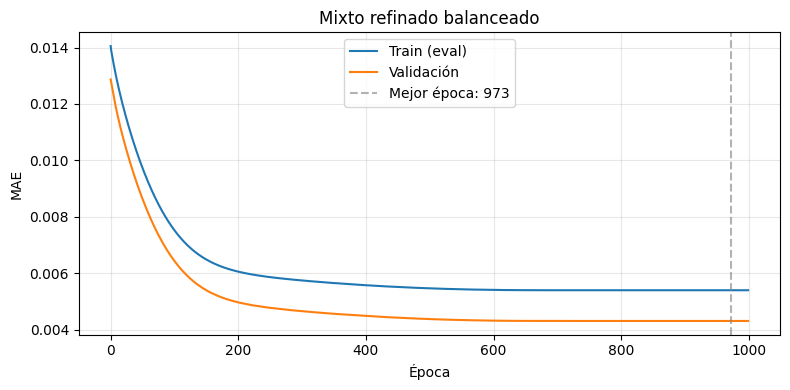

In [33]:
# Refinamiento largo del modelo Mixto.
# Resultado bruto de referencia:
# Se parte del Mixto bruto calculado arriba para esta ventana.
# Probamos menos filtros/unidades y mas regularizacion para mejorar generalizacion.

candidatos_mixto = [
    {'nombre': 'Mixto_24_16_reg', 'filtros': 24, 'lstm_units': 16, 'dropout': 0.40, 'l2': 1e-4, 'lr': 5e-5},
    {'nombre': 'Mixto_16_12_reg', 'filtros': 16, 'lstm_units': 12, 'dropout': 0.35, 'l2': 1e-4, 'lr': 3e-5},
    {'nombre': 'Mixto_24_12_reg_fuerte', 'filtros': 24, 'lstm_units': 12, 'dropout': 0.45, 'l2': 2e-4, 'lr': 5e-5},
]

resultados_mixto_balanceados = []
historias_mixto_balanceadas = {}
modelos_mixto_balanceados = {}

for candidato in candidatos_mixto:
    nombre = candidato['nombre']
    cfg = {
        **candidato,
        'epochs': 1000,
        'batch_size': 256,
        'factor': 0.90,
        'rlr_patience': 70,
        'min_delta': 1e-8,
        'min_lr': 5e-7,
        'es_patience': 220,
        'restore_best_weights': True,
        'seed': 42,
        'clipnorm': 0.5,
        'verbose': 0,
        'track_train_eval': True,
        'gap_metric': 'train_eval_loss',
        'es_monitor': 'balanced_score',
        'rlr_monitor': 'balanced_score',
        'gap_target': 1e-4,
        'gap_weight': 2.0,
        'gap_excess_weight': 8.0,
    }
    cfg.pop('nombre')

    print(f'Entrenando {nombre}...')
    score, best_val, best_epoch, best_train, best_gap, hist, model = modelos_mod._train_one(
        'construir_mixto_param', cfg, X_train, y_train, X_val, y_val
    )

    met = evaluar_modelo(model, X_train, y_train, X_val, y_val, X_test, y_test, nombre=nombre)
    met['gap_train_val'] = abs(met['mae_train'] - met['mae_val'])
    met['gap_train_test'] = abs(met['mae_train'] - met['mae_test'])
    met['best_train_val_gap'] = best_gap
    met['best_epoch'] = best_epoch
    met['balanced_score'] = score

    resultados_mixto_balanceados.append(met)
    historias_mixto_balanceadas[nombre] = hist
    modelos_mixto_balanceados[nombre] = model

df_mixto_balanceados = pd.DataFrame(resultados_mixto_balanceados).sort_values(
    ['best_train_val_gap', 'gap_train_val', 'mae_test']
).reset_index(drop=True)

display(df_mixto_balanceados[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'gap_train_val', 'gap_train_test', 'best_train_val_gap', 'best_epoch', 'n_params'
]])

mejor_mixto = df_mixto_balanceados.loc[0, 'modelo']
modelo_mixto_balanceado = modelos_mixto_balanceados[mejor_mixto]
hist_mixto_balanceado = historias_mixto_balanceadas[mejor_mixto]
resultado_mixto_balanceado = df_mixto_balanceados.loc[0].to_dict()
resultado_mixto_balanceado['modelo'] = 'Mixto_param_refinado_balanceado'

print('Mejor Mixto refinado:', mejor_mixto)
print(resultado_mixto_balanceado)
plot_best_history(hist_mixto_balanceado, 'Mixto refinado balanceado')


## 1.7 Resumen de competicion y guardado


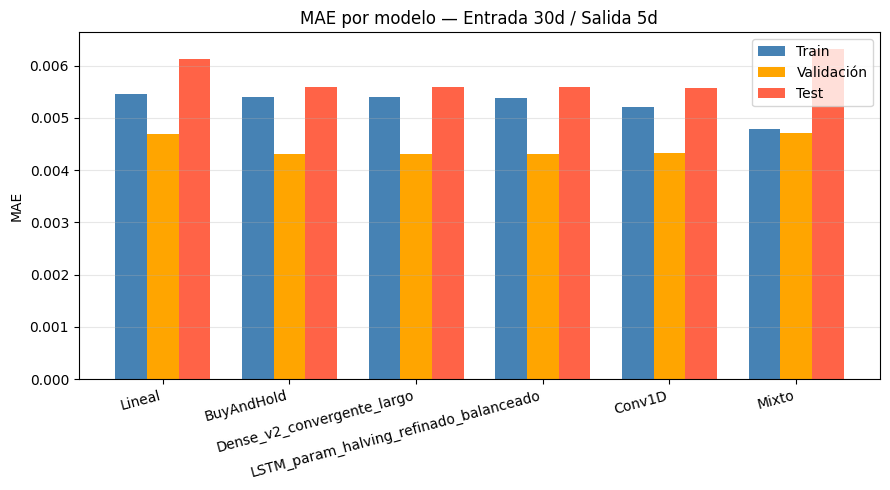

Resultados [competicion] guardados en: ../resultados/metricas/ent30_sal05.json


,mae_train,mae_val,mae_test,n_params,funcion,best_val_loss,best_epoch,best_cfg,gap_train_val,best_train_eval_loss,best_train_val_gap,gap_train_test,balanced_score
modelo,,,,,,,,,,,,,
Lineal,0.005465,0.004693,0.006122,15893,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BuyAndHold,0.005396,0.004302,0.005585,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dense_v2_convergente_largo,0.005394,0.004306,0.005585,72743,construir_dense_v2,0.004305,382.0,NaN,0.001089,0.005394,0.001089,NaN,NaN
LSTM_param_halving_refinado_balanceado,0.005386,0.004305,0.005583,2951,NaN,0.005064,600.0,NaN,0.001081,0.006145,0.001081,0.000197,0.019296
Conv1D,0.005206,0.004321,0.005578,11415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mixto,0.004780,0.004709,0.006320,38999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
resultados_competicion = [
    resultado_lineal, resultado_bah,
    resultado_dense, resultado_lstm,
    resultado_conv,  resultado_mixto,
]
graficar_barras_mae(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA)
guardar_resultados(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA, seccion='competicion')
display(pd.DataFrame(resultados_competicion).set_index('modelo').round(6))


---
# PARTE 2 — Investigacion
Preprocesado del Taller B3-T1 (Lopez de Prado):
1. **FFD** sobre log-retornos (Snippets 5.3-5.4, *Advances in Financial ML* 2018)
2. **Denoising Marchenko-Pastur** (*ML for Asset Managers* 2020)
3. **StandardScaler** ajustado solo sobre train


## 2.1 Diferenciacion fraccional (FFD)
Se aplica sobre **log-retornos** con ventana maxima de 500 pasos para
garantizar que siempre haya suficientes observaciones tras la transformacion.


In [35]:
# ── Snippet 5.3: pesos FFD con ventana maxima ───────────────────────────
def get_weights_ffd(d, threshold=1e-5, max_width=None):
    """Pesos para diferenciacion fraccional FFD. max_width limita la ventana."""
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k); k += 1
        if max_width and len(w) >= max_width:
            break
    return np.array(w[::-1])

# ── Snippet 5.4: aplicar FFD ─────────────────────────────────────────────
def frac_diff_ffd(series, d, threshold=1e-5, max_width=None):
    """Aplica FFD a una pd.Series. max_width trunca la ventana de pesos."""
    if max_width is None:
        max_width = len(series)          # no exceder la longitud de la serie
    weights = get_weights_ffd(d, threshold, max_width=max_width)
    width = len(weights)
    if width > len(series):
        return pd.Series(dtype=float)    # serie demasiado corta
    vals = series.values
    # Usar lista en lugar de dict para evitar desalineacion con DatetimeIndex
    result_vals = [
        np.dot(weights, vals[i - width + 1 : i + 1])
        for i in range(width - 1, len(vals))
    ]
    return pd.Series(result_vals, index=series.index[width - 1:])

def encontrar_d_minimo(serie, d_values=None, threshold=1e-5, pvalue=0.05):
    """
    Encuentra el minimo d que hace la serie estacionaria (ADF p-value < pvalue).
    Usa max_width = min(500, len(serie)//2) para que la ventana de pesos nunca
    consuma la serie completa y siempre queden observaciones suficientes.
    """
    if d_values is None:
        d_values = np.arange(0.1, 1.01, 0.1).round(1)
    serie_limpia = serie.replace([np.inf, -np.inf], np.nan).dropna()
    max_w = min(500, len(serie_limpia) // 2)   # ventana maxima: 500 o mitad de la serie
    for d in d_values:
        serie_diff = frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
        serie_diff = serie_diff.replace([np.inf, -np.inf], np.nan).dropna()
        if len(serie_diff) < 20:
            continue
        try:
            adf_pval = adfuller(serie_diff, autolag='AIC')[1]
        except Exception:
            continue
        if adf_pval < pvalue:
            return d, frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
    # Fallback: d=1 (primera diferencia), siempre estacionaria para retornos
    return 1.0, frac_diff_ffd(serie_limpia, 1.0, threshold, max_width=max_w)


d optimos por activo:
0.1    23
Name: count, dtype: int64

Forma tras FFD: (15691, 23)


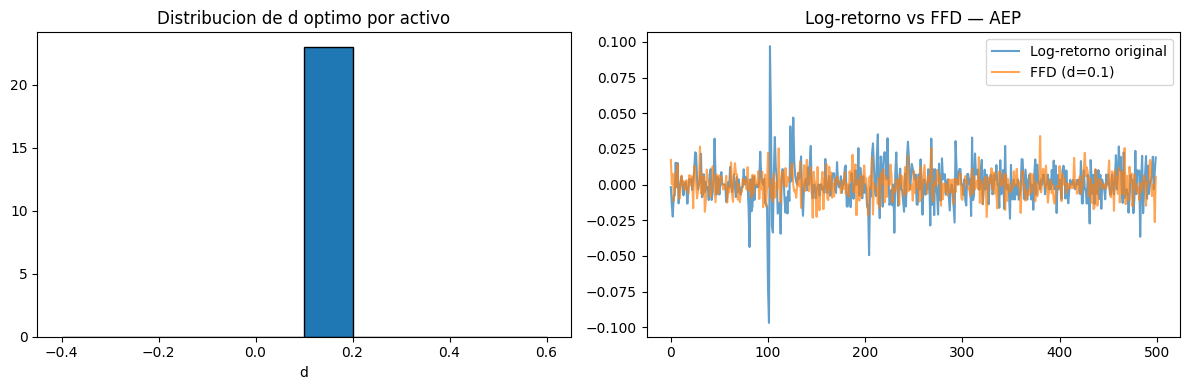

In [36]:
# FFD aplicada directamente sobre log-retornos.
# max_width=500 garantiza que la ventana de pesos no consuma la serie entera.

d_values = np.arange(0.1, 1.01, 0.1).round(1)
retornos_ffd = {}
d_optimos = {}

for ticker in retornos.columns:
    d_opt, serie_ffd = encontrar_d_minimo(retornos[ticker], d_values)
    d_optimos[ticker] = d_opt
    retornos_ffd[ticker] = serie_ffd

df_ffd = pd.DataFrame(retornos_ffd).dropna()
df_ffd = df_ffd.loc[:, df_ffd.std() > 1e-10]  # eliminar columnas constantes

print('d optimos por activo:')
print(pd.Series(d_optimos).value_counts().sort_index())
print(f'\nForma tras FFD: {df_ffd.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(list(d_optimos.values()), bins=10, edgecolor='black')
axes[0].set_title('Distribucion de d optimo por activo')
axes[0].set_xlabel('d')
ticker_ej = retornos.columns[0]
axes[1].plot(retornos[ticker_ej].values[:500],  label='Log-retorno original', alpha=0.7)
axes[1].plot(df_ffd[ticker_ej].values[:500],    label=f'FFD (d={d_optimos[ticker_ej]})', alpha=0.7)
axes[1].set_title(f'Log-retorno vs FFD — {ticker_ej}')
axes[1].legend()
plt.tight_layout(); plt.show()


## 2.2 Denoising Marchenko-Pastur
Fuente: Lopez de Prado (2020). La funcion incluye fallbacks para casos
donde la matriz no converge numericamente.


In [37]:
def mp_pdf(var, q, pts=1000):
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lmin, lmax, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt(np.maximum((lmax - x) * (x - lmin), 0))
    return x, pdf, lmax

def fit_kde(obs, bwidth=None, x=None):
    # bwidth adaptativo: 10% del rango de los datos
    if bwidth is None:
        r = obs.max() - obs.min()
        bwidth = max(0.01, r * 0.10)
    kde = KernelDensity(bandwidth=bwidth).fit(obs.reshape(-1, 1))
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    return x, np.exp(kde.score_samples(x.reshape(-1, 1)))

def err_pdfs(var, evals, q):
    if var <= 0:
        return 1e10
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    if lmax <= lmin:
        return 1e10
    x_mp, pdf_mp, _ = mp_pdf(var, q)
    _, pdf_kde = fit_kde(evals, x=x_mp)
    return float(np.sum((pdf_kde - pdf_mp) ** 2))

def find_max_eval(evals, q):
    # Normalizar eigenvalues para que el rango de busqueda sea significativo
    evals_flat = evals.flatten()
    evals_mean = evals_flat.mean()
    if evals_mean <= 0:
        evals_mean = 1.0
    evals_norm = evals_flat / evals_mean
    # Buscar var en [0.01, 3] sobre datos normalizados
    best_sse, best_var = np.inf, 1.0
    for var in np.linspace(0.01, 3.0, 60):
        sse = err_pdfs(var, evals_norm, q)
        if sse < best_sse:
            best_sse, best_var = sse, var
    # Refinamiento fino alrededor del mejor
    lo, hi = max(0.001, best_var * 0.5), best_var * 2.0
    try:
        res = minimize_scalar(err_pdfs, bounds=(lo, hi), method='bounded',
                              args=(evals_norm, q))
        if res.success and res.fun < best_sse:
            best_var = res.x
    except Exception:
        pass
    # lmax en escala original
    _, _, lmax_norm = mp_pdf(best_var, q)
    return lmax_norm * evals_mean

def denoised_corr(evals, evecs, n_signal):
    ev = evals.copy()
    noise = ev[n_signal:]
    if len(noise) > 0:
        ev[n_signal:] = noise.mean()
    corr = evecs @ np.diag(ev) @ evecs.T
    diag = np.sqrt(np.diag(corr))
    diag[diag == 0] = 1.0
    corr = corr / np.outer(diag, diag)
    np.fill_diagonal(corr, 1.0)
    return corr

def aplicar_denoising(returns_df):
    """
    Denoising Marchenko-Pastur sobre la matriz de covarianza.
    Devuelve (df_limpio, n_signal, lmax).
    """
    df = returns_df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(axis=1, how='any')
    df = df.loc[:, df.std() > 1e-10]

    if df.shape[1] < 2 or df.shape[0] < df.shape[1] + 5:
        return returns_df, 0, 1.0

    cov = df.cov().values
    if np.isnan(cov).any() or np.isinf(cov).any():
        return returns_df, 0, 1.0

    N = cov.shape[0]
    T = df.shape[0]
    q = T / N

    std = np.sqrt(np.diag(cov))
    std[std == 0] = 1.0
    corr = np.clip(cov / np.outer(std, std), -1, 1)
    np.fill_diagonal(corr, 1.0)

    try:
        evals, evecs = np.linalg.eigh(corr)
    except np.linalg.LinAlgError:
        print('AVISO: eigh no convergio, se devuelven datos sin denoising')
        return returns_df, 0, 1.0

    # eigh devuelve orden ascendente; invertir para descendente
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]
    evals = np.maximum(evals, 1e-10)   # evitar eigenvalues negativos por precision

    lmax = find_max_eval(evals.reshape(-1, 1), q)
    n_signal = max(1, min(N - 1, int(np.sum(evals > lmax))))

    corr_clean = denoised_corr(evals, evecs, n_signal)
    corr_clean = np.clip(corr_clean, -1, 1)
    np.fill_diagonal(corr_clean, 1.0)

    cov_clean = corr_clean * np.outer(std, std)
    cov_clean = (cov_clean + cov_clean.T) / 2 + 1e-6 * np.eye(N)

    try:
        L = np.linalg.cholesky(cov_clean)
        returns_clean = df.values @ np.linalg.inv(L).T
    except np.linalg.LinAlgError:
        print('AVISO: Cholesky no convergio, se devuelven datos sin transformar')
        returns_clean = df.values

    result = pd.DataFrame(returns_clean, index=df.index, columns=df.columns)
    for col in returns_df.columns:
        if col not in result.columns:
            result[col] = returns_df[col]
    return result[returns_df.columns], n_signal, lmax


Autovalores de senyal: 1 / 23
Lambda_max (Marchenko-Pastur): 6.4682


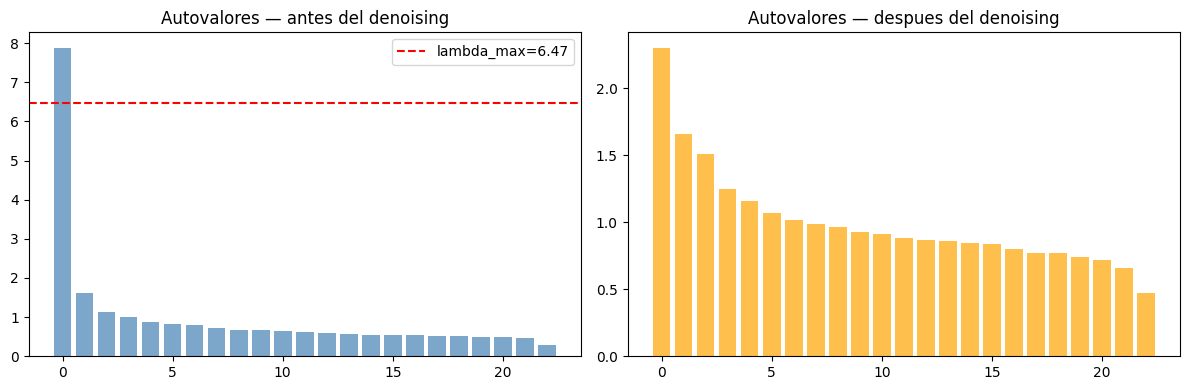

In [38]:
df_ffd_denoised, n_signal, lmax = aplicar_denoising(df_ffd)
print(f'Autovalores de senyal: {n_signal} / {df_ffd.shape[1]}')
print(f'Lambda_max (Marchenko-Pastur): {lmax:.4f}')

T, N = df_ffd.shape
corr_raw   = np.nan_to_num(df_ffd.corr().values, nan=0.0)
np.fill_diagonal(corr_raw, 1.0)
evals_raw   = np.sort(np.linalg.eigvalsh(corr_raw))[::-1]
corr_clean = np.nan_to_num(df_ffd_denoised.corr().values, nan=0.0)
np.fill_diagonal(corr_clean, 1.0)
evals_clean = np.sort(np.linalg.eigvalsh(corr_clean))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), evals_raw,   color='steelblue', alpha=0.7)
axes[0].axhline(lmax, color='red', linestyle='--', label=f'lambda_max={lmax:.2f}')
axes[0].set_title('Autovalores — antes del denoising'); axes[0].legend()
axes[1].bar(range(N), evals_clean, color='orange', alpha=0.7)
axes[1].set_title('Autovalores — despues del denoising')
plt.tight_layout(); plt.show()


## 2.3 Construccion de ventanas con datos preprocesados

In [39]:
df_prep = df_ffd_denoised
print(f'Serie preprocesada: {df_prep.shape}')
X_p, y_p = create_time_series_data(df_prep, VENTANA_ENTRADA, VENTANA_SALIDA)
X_tr_p, X_val_p, X_ts_p, y_tr_p, y_val_p, y_ts_p = dividir_datos(X_p, y_p)
n_tr, v, ch = X_tr_p.shape
scaler = StandardScaler()
X_tr_flat  = scaler.fit_transform(X_tr_p.reshape(n_tr, -1))
X_val_flat = scaler.transform(X_val_p.reshape(X_val_p.shape[0], -1))
X_ts_flat  = scaler.transform(X_ts_p.reshape(X_ts_p.shape[0],  -1))
X_tr_3d  = X_tr_flat.reshape(n_tr, v, ch)
X_val_3d = X_val_flat.reshape(X_val_p.shape[0], v, ch)
X_ts_3d  = X_ts_flat.reshape(X_ts_p.shape[0],  v, ch)
print(f'Train: {X_tr_3d.shape}  Val: {X_val_3d.shape}  Test: {X_ts_3d.shape}')


Serie preprocesada: (15691, 23)
Train: (13386, 30, 23)  Val: (705, 30, 23)  Test: (1566, 30, 23)


## 2.4 Mejor modelo de Parte 1 re-entrenado con preprocesado

Mejor modelo Parte 1 (redes neuronales): Conv1D
Epoch 1/100


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2824 - val_loss: 0.2368 - learning_rate: 0.0010
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2795 - val_loss: 0.2369 - learning_rate: 0.0010
Epoch 3/100
200/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2801
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2789 - val_loss: 0.2371 - learning_rate: 0.0010
Epoch 4/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2781 - val_loss: 0.2370 - learning_rate: 5.0000e-04
Epoch 5/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2776 - val_loss: 0.2372 - learning_rate: 5.0000e-04
Epoch 6/100
205/210 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2783
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2772 - val_loss: 0.2373 - learning_rate: 5.0000e-04
Epoch 7/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2766 - 

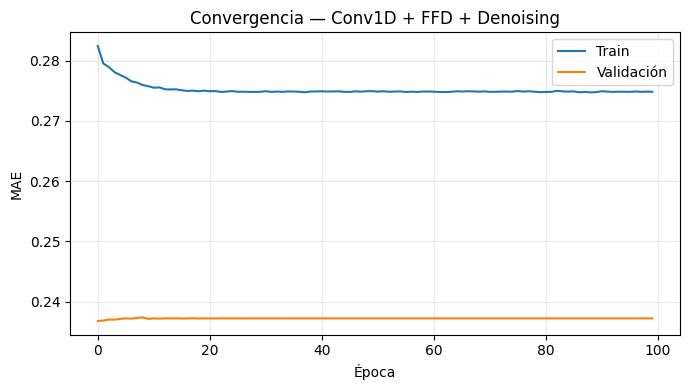

In [40]:
df_comp = pd.DataFrame(resultados_competicion)
modelos_nn = ('Dense', 'LSTM', 'Conv1D', 'Mixto')
df_nn = df_comp[df_comp['modelo'].isin(modelos_nn)]
mejor_nombre = df_nn.loc[df_nn['mae_test'].idxmin(), 'modelo']
print(f'Mejor modelo Parte 1 (redes neuronales): {mejor_nombre}')
usa_plano = mejor_nombre in ('Dense', 'Lineal')
constructores_prep = {
    'Dense':  lambda: construir_dense(X_tr_flat.shape[1], y_tr_p.shape[1]),
    'LSTM':   lambda: construir_recurrente(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Conv1D': lambda: construir_conv1d(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Mixto':  lambda: construir_mixto(X_tr_3d.shape[1:], y_tr_p.shape[1]),
}
modelo_prep = constructores_prep[mejor_nombre]()
X_fit     = X_tr_flat  if usa_plano else X_tr_3d
X_fit_val = X_val_flat if usa_plano else X_val_3d
X_fit_ts  = X_ts_flat  if usa_plano else X_ts_3d
hist_prep = modelo_prep.fit(
    X_fit, y_tr_p,
    validation_data=(X_fit_val, y_val_p),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)
graficar_convergencia(hist_prep, f'{mejor_nombre} + FFD + Denoising')
resultado_prep = evaluar_modelo(
    modelo_prep, X_fit, y_tr_p,
    X_fit_val, y_val_p, X_fit_ts, y_ts_p,
    nombre=f'{mejor_nombre}_prep')
print(resultado_prep)


## 2.5 Comparativa con/sin preprocesado y guardado

,mae_train,mae_val,mae_test,n_params
modelo,,,,
Conv1D,0.005206,0.004321,0.005578,11415
Conv1D_prep,0.273804,0.237256,0.292693,11415


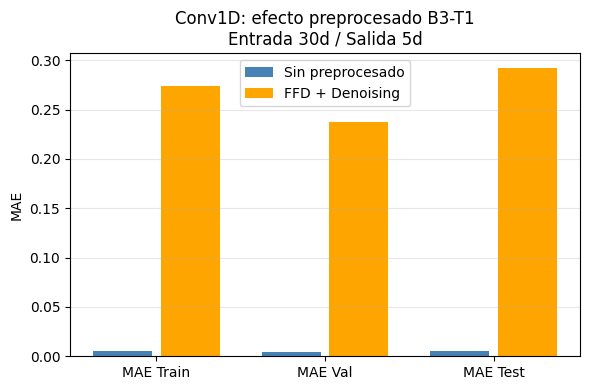

Variacion MAE test con preprocesado: -5147.1%
Resultados [investigacion] guardados en: ../resultados/metricas/ent30_sal05.json


In [41]:
resultado_sin_prep = df_comp[df_comp['modelo'] == mejor_nombre].iloc[0].to_dict()
comparativa = pd.DataFrame([resultado_sin_prep, resultado_prep])\
    .set_index('modelo')[['mae_train','mae_val','mae_test','n_params']].round(6)
display(comparativa)
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
ax.bar(x - 0.2, [resultado_sin_prep['mae_train'],
                  resultado_sin_prep['mae_val'],
                  resultado_sin_prep['mae_test']], 0.35,
       label='Sin preprocesado', color='steelblue')
ax.bar(x + 0.2, [resultado_prep['mae_train'],
                  resultado_prep['mae_val'],
                  resultado_prep['mae_test']], 0.35,
       label='FFD + Denoising', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['MAE Train', 'MAE Val', 'MAE Test'])
ax.set_ylabel('MAE')
ax.set_title(f'{mejor_nombre}: efecto preprocesado B3-T1\n'
             f'Entrada {VENTANA_ENTRADA}d / Salida {VENTANA_SALIDA}d')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
mejora = (resultado_sin_prep['mae_test'] - resultado_prep['mae_test']) / resultado_sin_prep['mae_test'] * 100
print(f'Variacion MAE test con preprocesado: {mejora:+.1f}%')
guardar_resultados([resultado_prep], VENTANA_ENTRADA, VENTANA_SALIDA, seccion='investigacion')
